In [1]:
import pandas as pd

In [2]:
#Part 1: Data Loading & Structure
df=pd.read_table('bank_marketing_training.txt', sep=',')
df.head(10)

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,days_since_previous,previous,previous_outcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,response
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191,no
2,41,blue-collar,married,unknown,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191,no
3,25,services,single,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191,no
4,29,blue-collar,single,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191,no
5,57,housemaid,divorced,basic.4y,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191,no
6,35,blue-collar,married,basic.6y,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191,no
7,39,management,single,basic.9y,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191,no
8,30,unemployed,married,high.school,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191,no
9,55,retired,single,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191,no


In [3]:
obs=len(df)
print('Number of observation',obs)
vrb=len(df.columns)
print('Number of variable',vrb)

Number of observation 26874
Number of variable 21


In [4]:
#Display columns name
df.columns

Index(['age', 'job', 'marital', 'education', 'default', 'housing', 'loan',
       'contact', 'month', 'day_of_week', 'duration', 'campaign',
       'days_since_previous', 'previous', 'previous_outcome', 'emp.var.rate',
       'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed',
       'response'],
      dtype='object')

In [35]:
#Display data type for each column
df.dtypes

age                      int64
job                     object
marital                 object
education               object
default                 object
housing                 object
loan                    object
contact                 object
month                   object
day_of_week             object
duration                 int64
campaign                 int64
days_since_previous      int64
previous                 int64
previous_outcome        object
emp.var.rate           float64
cons.price.idx         float64
cons.conf.idx          float64
euribor3m              float64
nr.employed              int64
response                object
dtype: object

In [39]:
#Count missing value in each column
df.isnull().sum()

age                    0
job                    0
marital                0
education              0
default                0
housing                0
loan                   0
contact                0
month                  0
day_of_week            0
duration               0
campaign               0
days_since_previous    0
previous               0
previous_outcome       0
emp.var.rate           0
cons.price.idx         0
cons.conf.idx          0
euribor3m              0
nr.employed            0
response               0
dtype: int64

In [123]:
#Count duplicate row
Count_duplicate=df.duplicated().sum()
print(Count_duplicate)

4


In [36]:
#Written response (short): Is the dataset immediately ready for modeling? Why or why not?
print('We may need to clean up the data before modeling because there is missing value and 4 duplicates which can be a problem')

We may need to clean up the data before modeling because there is missing value and 4 duplicates which can be a problem


In [7]:
#Part 2: Variable Classification & Modeling Implications
# 1. Which variables must be encoded before modeling?
print('All categorical variable(dtype:object) must be encoded before modeling since most model require numerical input.')
# 2. Which variables might benefit from scaling?
print('Some model numerical variable might benefit from scaling if they are on a very different range because it can help prevent larger value variable from dominating the model') 
# 3. Identify the target variable.
print('the target variable in this dataset is response because it indicates whether the client subscribed to a term deposit')

All categorical variable(dtype:object) must be encoded before modeling since most model require numerical input.
Some model numerical variable might benefit from scaling if they are on a very different range because it can help prevent larger value variable from dominating the model
the target variable in this dataset is response because it indicates whether the client subscribed to a term deposit


In [53]:
# Part 3: Numerical Variable Exploration
# 1. Compute summary statistics: mean, median, standard deviation, min, max.?
#Numerical variable are ['age','duration','campaign','days_since_previous','previous','emp.var.rate','cons.price.idx','cons.conf.idx','euribor3m','nr.employed']

In [8]:
df.describe()

,age,duration,campaign,days_since_previous,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,26874.000000,26874.000000,26874.000000,26874.000000,26874.000000,26874.000000,26874.000000,26874.000000,26874.000000,26874.000000
mean,39.987758,257.741907,2.563035,962.714631,0.171058,0.086552,93.575794,-40.481670,3.627879,5167.103446
std,10.400285,258.977140,2.748746,186.324546,0.487657,1.569716,0.578933,4.626506,1.731948,72.080534
min,17.000000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.000000
25%,32.000000,103.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.000000
50%,38.000000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.000000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.000000
max,91.000000,4918.000000,43.000000,999.000000,6.000000,1.400000,94.767000,-26.900000,5.045000,5228.000000


In [9]:
age_mean=df['age'].mean().round(3)
age_median=df['age'].median().round(3)
age_std=df['age'].std().round(3)
age_min=df['age'].min().round(3)
age_max=df['age'].max().round(3)
duration_mean=df['duration'].mean().round(3)
duration_median=df['duration'].median().round(3)
duration_std=df['duration'].std().round(3)
duration_min=df['duration'].min().round(3)
duration_max=df['duration'].max().round(3)
campaign_mean=df['campaign'].mean().round(3)
campaign_median=df['campaign'].median().round(3)
campaign_std=df['campaign'].std().round(3)
campaign_min=df['campaign'].min().round(3)
campaign_max=df['campaign'].max().round(3)
days_since_previous_mean=df['days_since_previous'].mean().round(3)
days_since_previous_median=df['days_since_previous'].median().round(3)
days_since_previous_std=df['days_since_previous'].std().round(3)
days_since_previous_min=df['days_since_previous'].min().round(3)
days_since_previous_max=df['days_since_previous'].max().round(3)
previous_mean=df['previous'].mean().round(3)
previous_median=df['previous'].median().round(3)
previous_std=df['previous'].std().round(3)
previous_min=df['previous'].min().round(3)
previous_max=df['previous'].max().round(3)
emp_mean=df['emp.var.rate'].mean().round(3)
emp_median=df['emp.var.rate'].median().round(3)
emp_std=df['emp.var.rate'].std().round(3)
emp_min=df['emp.var.rate'].min().round(3)
emp_max=df['emp.var.rate'].max().round(3)
cons_price_mean=df['cons.price.idx'].mean().round(3)
cons_price_median=df['cons.price.idx'].median().round(3)
cons_price_std=df['cons.price.idx'].std().round(3)
cons_price_min=df['cons.price.idx'].min().round(3)
cons_price_max=df['cons.price.idx'].max().round(3)
cons_conf_mean=df['cons.conf.idx'].mean().round(3)
cons_conf_median=df['cons.conf.idx'].median().round(3)
cons_conf_std=df['cons.conf.idx'].std().round(3)
cons_conf_min=df['cons.conf.idx'].min().round(3)
cons_conf_max=df['cons.conf.idx'].max().round(3)
euribor3m_mean=df['euribor3m'].mean().round(3)
euribor3m_median=df['euribor3m'].median().round(3)
euribor3m_std=df['euribor3m'].std().round(3)
euribor3m_min=df['euribor3m'].min().round(3)
euribor3m_max=df['euribor3m'].max().round(3)
nr_mean=df['nr.employed'].mean().round(3)
nr_median=df['nr.employed'].median().round(3)
nr_std=df['nr.employed'].std().round(3)
nr_min=df['nr.employed'].min().round(3)
nr_max=df['nr.employed'].max().round(3)

In [10]:
print('Age:','mean',age_mean,'median',age_median,'standard deviation',age_std,'min',age_min,'max',age_max)
print('Duration:','mean',duration_mean,'median',duration_median,'standard deviation',duration_std,'min',duration_min,'max',duration_max)
print('Campaign:','mean',campaign_mean,'median',campaign_median,'standard deviation',campaign_std,'min',campaign_min,'max',campaign_max)
print('Days since previous:','mean',days_since_previous_mean,'median',days_since_previous_median,'standard deviation',days_since_previous_std,'min',days_since_previous_min,'max',days_since_previous_max)
print('Previous:','mean',previous_mean,'median',previous_median,'standard deviation',previous_std,'min',previous_min,'max',previous_max)
print('Emp.var.rate:','mean',emp_mean,'median',emp_median,'standard deviation',emp_std,'min',emp_min,'max',emp_max)
print('Cons.price.idx:','mean',cons_price_mean,'median',cons_price_median,'standard deviation',cons_price_std,'min',cons_price_min,'max',cons_price_max)
print('Cons.conf.idx:','mean',cons_conf_mean,'median',cons_conf_median,'standard deviation',cons_conf_std,'min',cons_conf_min,'max',cons_conf_max)
print('Euribor3m:','mean',euribor3m_mean,'median',euribor3m_median,'standard deviation',euribor3m_std,'min',euribor3m_min,'max',euribor3m_max)
print('nr.employed:','mean',nr_mean,'median',nr_median,'standard deviation',nr_std,'min',nr_min,'max',nr_max)

Age: mean 39.988 median 38.0 standard deviation 10.4 min 17 max 91
Duration: mean 257.742 median 180.0 standard deviation 258.977 min 0 max 4918
Campaign: mean 2.563 median 2.0 standard deviation 2.749 min 1 max 43
Days since previous: mean 962.715 median 999.0 standard deviation 186.325 min 0 max 999
Previous: mean 0.171 median 0.0 standard deviation 0.488 min 0 max 6
Emp.var.rate: mean 0.087 median 1.1 standard deviation 1.57 min -3.4 max 1.4
Cons.price.idx: mean 93.576 median 93.749 standard deviation 0.579 min 92.201 max 94.767
Cons.conf.idx: mean -40.482 median -41.8 standard deviation 4.627 min -50.8 max -26.9
Euribor3m: mean 3.628 median 4.857 standard deviation 1.732 min 0.634 max 5.045
nr.employed: mean 5167.103 median 5191.0 standard deviation 72.081 min 4963 max 5228


In [ ]:
!pip install matplotlib

<Axes: title={'center': 'Histogram of Age'}, ylabel='Frequency'>

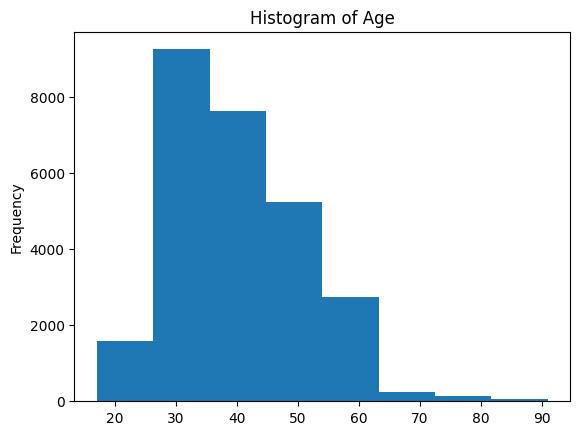

In [127]:
df['age'].plot(kind='hist', bins=8, title='Histogram of Age')

<Axes: title={'center': 'Histogram of Duration'}, ylabel='Frequency'>

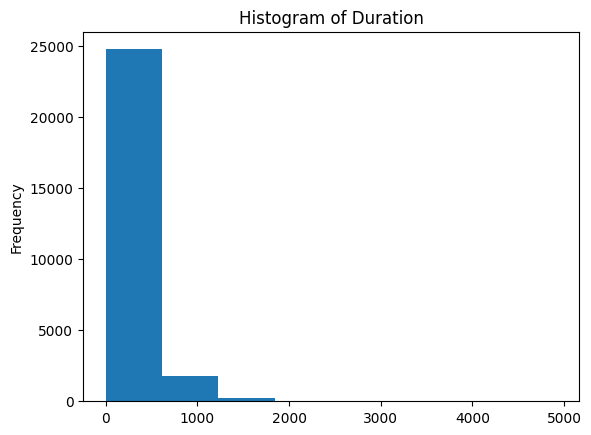

In [128]:
df['duration'].plot(kind='hist', bins=8, title='Histogram of Duration')

<Axes: title={'center': 'Boxplot of Age'}>

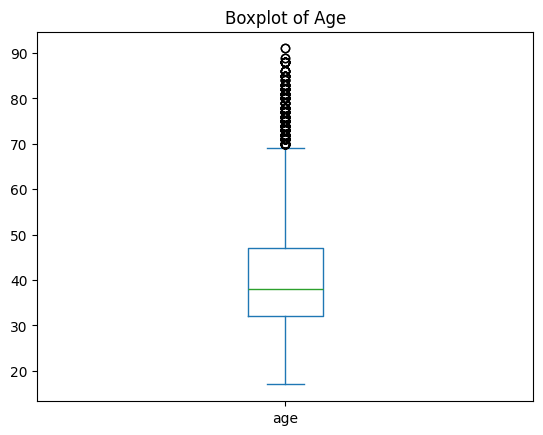

In [132]:
df['age'].plot(kind='box', title='Boxplot of Age')

<Axes: title={'center': 'Boxplot of Duration'}>

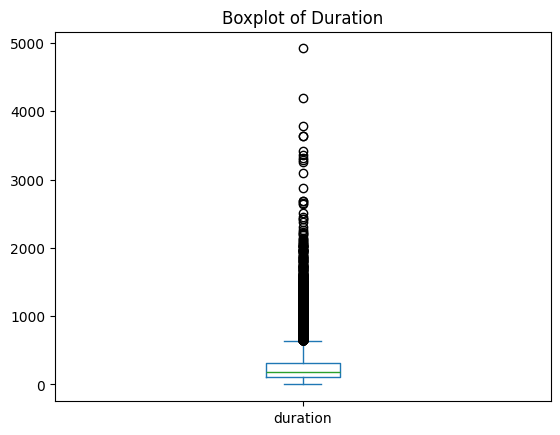

In [135]:
df['duration'].plot(kind='box', title='Boxplot of Duration')

In [139]:
#Duration variables appear more skewed compare to Age
#Would skewed variables or outliers affect certain algorithms?
#Skewed variables and outliers can affect certain algorithms in case of linear regression data are normally distributed, skewness can cause data to become less accurate

In [32]:
#Part 4: Categorical Variable Exploration
#Choose at least 4 categorical variables and do the following for each:
#1. List the unique categories.
#2. Produce frequency counts.
#3. Create a bar chart of category counts.
cate_variables=['job', 'marital', 'education', 'housing']
for x in cate_variables:
    print(x,':',df[x].unique())
    print(df[x].value_counts())
    

job : ['housemaid' 'services' 'blue-collar' 'management' 'unemployed' 'retired'
 'technician' 'admin.' 'unknown' 'entrepreneur' 'student' 'self-employed']
job
admin.           6757
blue-collar      6051
technician       4437
services         2581
management       1889
retired          1143
self-employed     918
entrepreneur      914
housemaid         709
unemployed        667
student           598
unknown           210
Name: count, dtype: int64
marital : ['married' 'single' 'divorced' 'unknown']
marital
married     16187
single       7575
divorced     3055
unknown        57
Name: count, dtype: int64
education : ['basic.4y' 'high.school' 'unknown' 'basic.6y' 'basic.9y'
 'university.degree' 'professional.course' 'illiterate']
education
university.degree      7946
high.school            6130
basic.9y               4050
professional.course    3423
basic.4y               2688
basic.6y               1498
unknown                1127
illiterate               12
Name: count, dtype: int64
housin

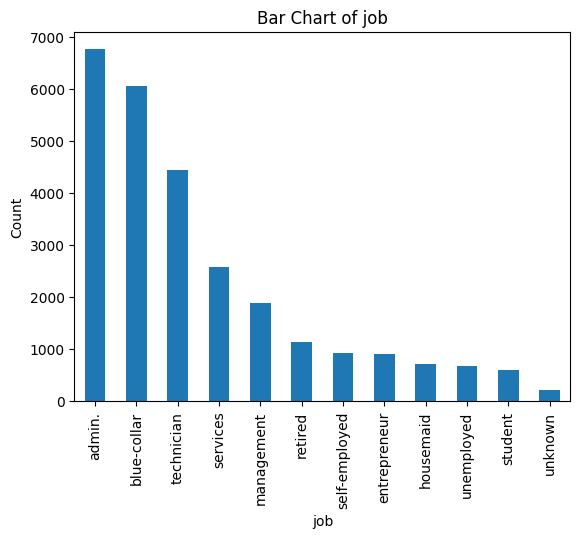

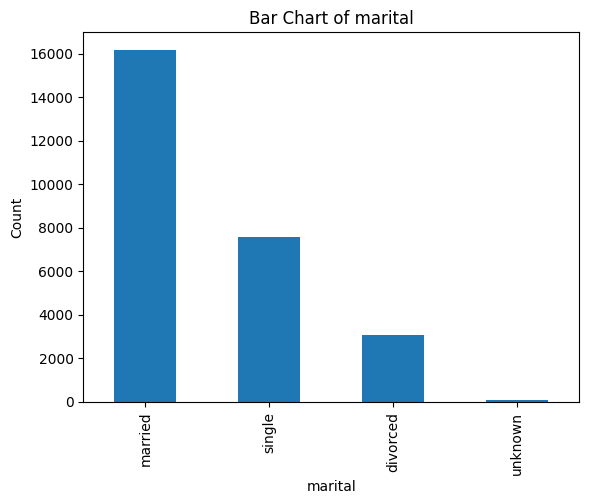

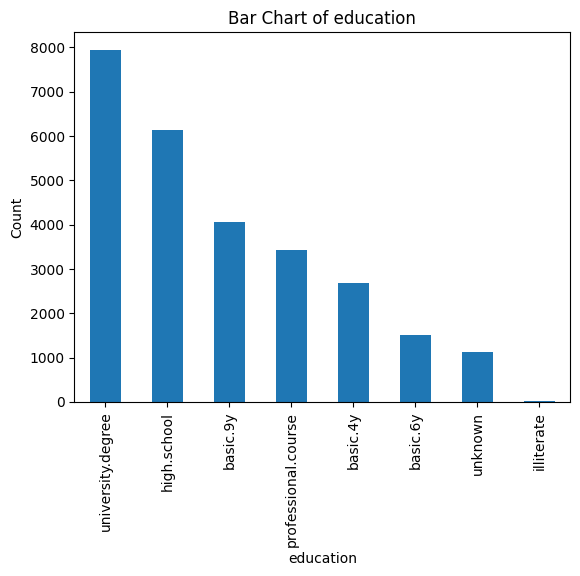

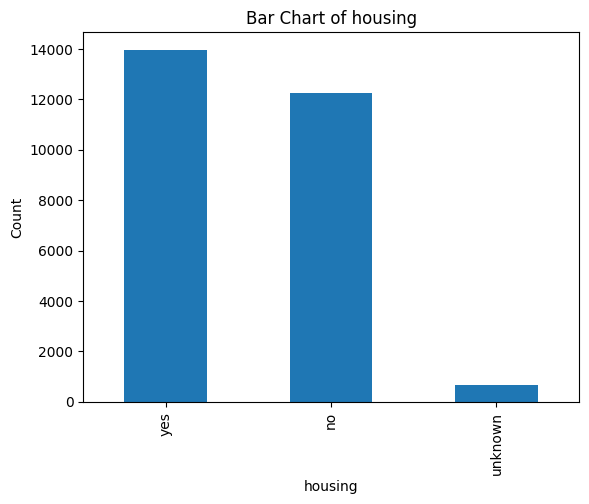

In [16]:
import matplotlib.pyplot as plt
for x in cate_variables:
    df[x].value_counts().plot(kind='bar', title=f'Bar Chart of {x}')
    plt.ylabel('Count')
    plt.show()

In [1]:
# 1. Are there categories with very small frequency that may cause modeling instability?
# Yes (illiterate in education)
# 2. Would you group/merge any categories? Why?
# No, because there is only one rare category. I will consider merging if there are multiple rare group to generalized them 
# 3. Why might rare categories create issues for modeling?
# The model will remember the rare categories and perform well on testing data but might perform poorly on other data.


In this case we will choose Job as target variable
Frequency counts
job
admin.           6757
blue-collar      6051
technician       4437
services         2581
management       1889
retired          1143
self-employed     918
entrepreneur      914
housemaid         709
unemployed        667
student           598
unknown           210
Name: count, dtype: int64
Percentages
job
admin.           25.143
blue-collar      22.516
technician       16.510
services          9.604
management        7.029
retired           4.253
self-employed     3.416
entrepreneur      3.401
housemaid         2.638
unemployed        2.482
student           2.225
unknown           0.781
Name: proportion, dtype: float64


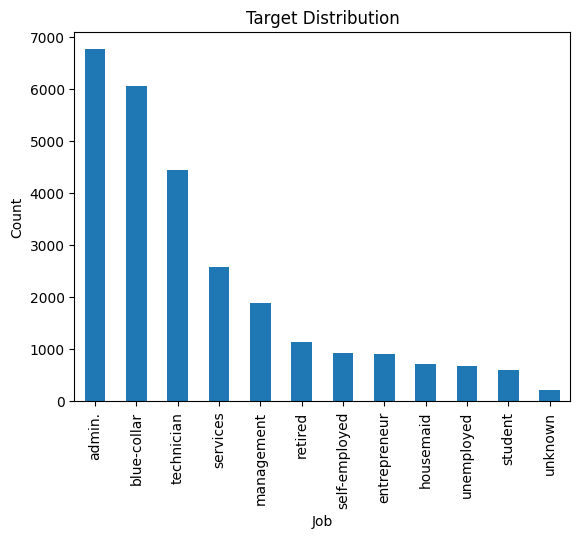

Dataset is imbalanced


In [35]:
# Part 5: Target Variable Analysis 
# 1. Identify the target variable (the response/outcome column).
print('In this case we will choose Job as target variable')
# 2. Compute frequency counts and percentages for the target classes.
# Frequency counts
print('Frequency counts')
job_counts = df['job'].value_counts()
print(job_counts)
# Percentages
print('Percentages')
job_percentages = df['job'].value_counts(normalize=True)*100 #normalize=True converts counts into proportions instead of raw counts.
print(job_percentages.round(3))
# 3. Create a bar chart of the target distribution.
job_counts.plot(kind='bar')
plt.xlabel("Job")
plt.ylabel("Count")
plt.title("Target Distribution")
plt.show()
# 4. Determine whether the dataset is balanced or imbalanced.
min_ratio = job_percentages.min()
if min_ratio < 40:
    print("Dataset is imbalanced")
else:
    print("Dataset is balanced")
# 5. Written response (short): Why does class imbalance matter in classification problems?
# Class imbalance matter because in most modeling are designed to maximize accuracy and this imbalance can be a problem for overall accuracy
# Name one metric that can be more informative than accuracy.
# We can try using F1 score because the formula can measure the precision of the data

In [57]:
# Part 6: Simple Pattern Exploration 
# A. Numerical vs. Target
# Choose 2 numerical variables: 'age','duration'
# 1. Compare the mean of each variable across the target classes.
#The target variable indicates whether the client subscribed to a term deposit, 'response'
target='response'
df.groupby(target)[['age', 'duration']].mean().round(3)


,age,duration
response,,
no,39.893,221.055
yes,40.744,551.016


C:\Users\racha\AppData\Local\Temp\ipykernel_27624\1908933222.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([age_0, age_1], labels=['0','1'])
C:\Users\racha\AppData\Local\Temp\ipykernel_27624\1908933222.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([duration_0, duration_1], labels=['0','1'])


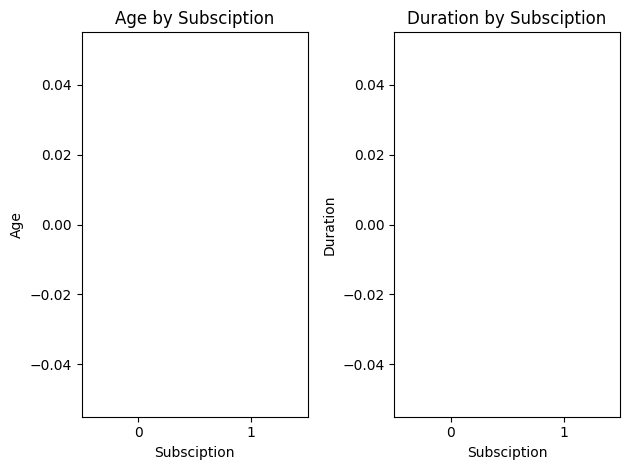

In [59]:
# 2. Create side-by-side boxplots of each variable by target class.
age_0 = df[df[target] == 0]['age']
age_1 = df[df[target] == 1]['age']

duration_0 = df[df[target] == 0]['duration']
duration_1 = df[df[target] == 1]['duration']
# Age Boxplot 
plt.subplot(1,2,1)
plt.boxplot([age_0, age_1], labels=['0','1'])
plt.title("Age by Subsciption")
plt.xlabel("Subsciption")
plt.ylabel("Age")

# Duration Boxplot 
plt.subplot(1,2,2)
plt.boxplot([duration_0, duration_1], labels=['0','1'])
plt.title("Duration by Subsciption")
plt.xlabel("Subsciption")
plt.ylabel("Duration")

plt.tight_layout()
plt.show()
# 3. Written response (short): Do you see separation between classes? What does it suggest?

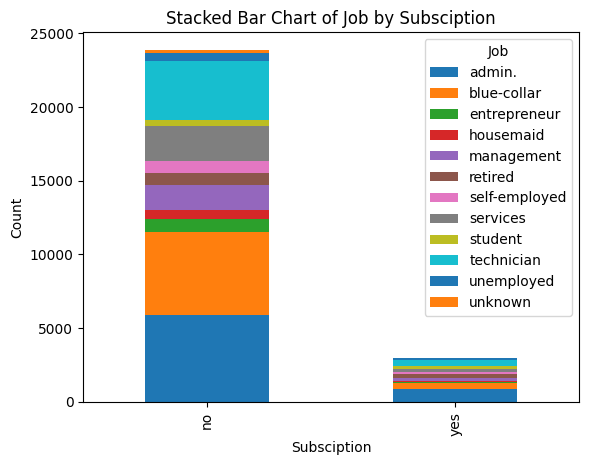

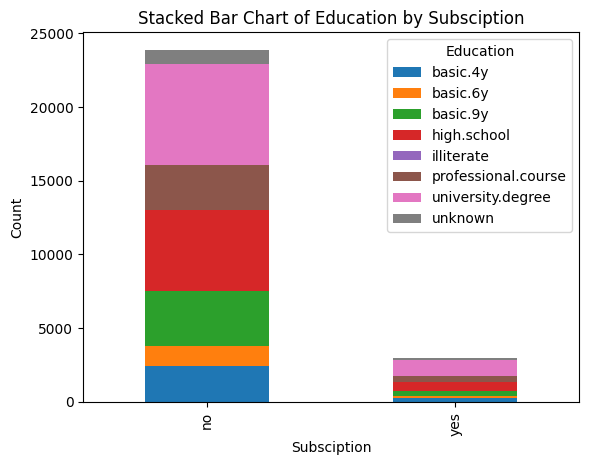

Those with Job (Blue collar anmd unemployed) and Education (University degree and highschool) are associated with higher subscription rate


In [30]:
# B. Categorical vs. Target
# Choose 2 categorical variables:'job', 'education'
# 1. Create a cross-tabulation (contingency table) with the target. A cross-tabulation shows the relationship between two categorical variables.
pd.crosstab(df['response'], df['job'])
pd.crosstab(df['response'], df['education'])
# 2. Create a stacked bar chart (or grouped bar chart) showing the relationship with the target.
cjob=pd.crosstab(df['response'], df['job'])
cjob.plot(kind='bar', stacked=True)
plt.title("Stacked Bar Chart of Job by Subsciption")
plt.xlabel("Subsciption")
plt.ylabel("Count")
plt.legend(title="Job")
plt.show()
cedu=pd.crosstab(df['response'], df['education'])
cedu.plot(kind='bar', stacked=True)
plt.title("Stacked Bar Chart of Education by Subsciption")
plt.xlabel("Subsciption")
plt.ylabel("Count")
plt.legend(title="Education")
plt.show()
# 3. Written response (short): Which categories seem associated with higher subscription rates?
print('Those with Job (Blue collar anmd unemployed) and Education (University degree and highschool) are associated with higher subscription rate')

In [7]:
# Part 7: Correlation & Redundancy 
# 1. Compute the correlation matrix for numerical variables.
numeric_df = df.select_dtypes(include=['int64', 'float64'])
correlation_matrix = numeric_df.corr()
print(correlation_matrix)

                          age  duration  campaign  days_since_previous  \
age                  1.000000 -0.002279  0.010078            -0.019291   
duration            -0.002279  1.000000 -0.070610            -0.043671   
campaign             0.010078 -0.070610  1.000000             0.050583   
days_since_previous -0.019291 -0.043671  0.050583             1.000000   
previous             0.017802  0.016720 -0.076767            -0.583636   
emp.var.rate         0.001501 -0.028119  0.147471             0.271675   
cons.price.idx      -0.002594  0.001103  0.125850             0.082127   
cons.conf.idx        0.129392 -0.002903 -0.015290            -0.089847   
euribor3m            0.013896 -0.031097  0.131810             0.297034   
nr.employed         -0.012633 -0.043245  0.141184             0.370888   

                     previous  emp.var.rate  cons.price.idx  cons.conf.idx  \
age                  0.017802      0.001501       -0.002594       0.129392   
duration             0.016720

         Variable1       Variable2  Correlation
56    emp.var.rate  cons.price.idx     0.776358
58    emp.var.rate       euribor3m     0.972313
59    emp.var.rate     nr.employed     0.907439
65  cons.price.idx    emp.var.rate     0.776358
85       euribor3m    emp.var.rate     0.972313
89       euribor3m     nr.employed     0.944971
95     nr.employed    emp.var.rate     0.907439
98     nr.employed       euribor3m     0.944971


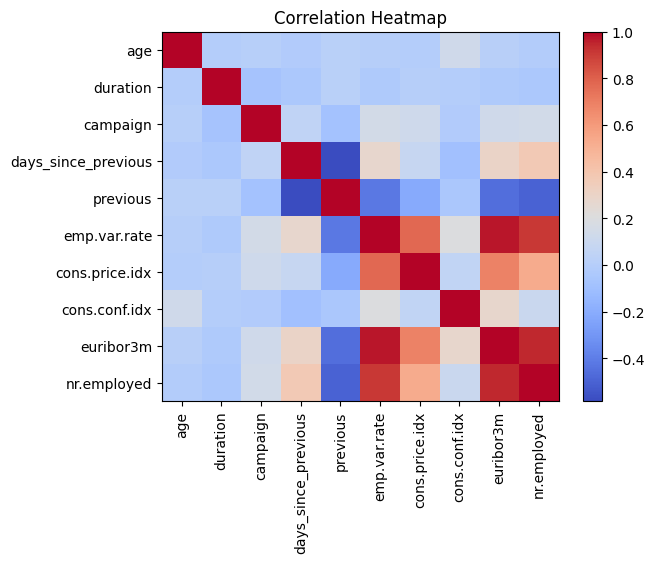

High correlation matter for logistic model because it can increase variance and unstable coefficient.This matter less for decision trees because tree split on one variable at a time and does not estimate coefficients


In [29]:
# 2. Identify any pairs with correlation above 0.7 (absolute value).
corr_matrix = df.select_dtypes(include=['int64','float64']).corr()
abs_corr = corr_matrix.abs()
high_corr = (
    abs_corr.unstack()
            .reset_index())

high_corr.columns = ['Variable1', 'Variable2', 'Correlation']
# Remove self-correlations (correlation = 1)
high_corr = high_corr[high_corr['Variable1'] != high_corr['Variable2']]
# Keep only correlations above 0.7
high_corr = high_corr[high_corr['Correlation'] > 0.7]
print(high_corr)
# 3. Create a correlation heatmap.
plt.imshow(corr_matrix, cmap='coolwarm', aspect='auto')
plt.colorbar()
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=90)
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)

plt.title("Correlation Heatmap")
plt.show()
# 4. Written response (short): Why might high correlation matter for some models (e.g., logistic
# regression) but not others (e.g., decision trees)?
print('High correlation matter for logistic model because it can increase variance and unstable coefficient.This matter less for decision trees because tree split on one variable at a time and does not estimate coefficients')

In [25]:
# Part 8: Business Analytics Reflection
# Write 1–2 well-written paragraphs (in Markdown) answering:
# 1. What type of business problem is represented by this dataset?
print('This dataset represent a classification problem with two outcome to whether client subscribe to term deposit. I think in the business world this represent a direct marketing problem by predicting which customer is more likely to subscribe. This can help the bank target the right customer and reduce their cost on marketing.')
# 2. What challenges might arise when building a classification model?
print('If we take this model for example, in the banking dataset most client are shown to not subscribe. This can cause the model to predict mostly "No" on future data and missing on potential new customer. Some variable might not be useful in reflecting whether the client will subscribe (ex:days_since_previous).')  
# 3. If you had to start with one model, which would you choose and why?
print('If I had to start with one model, I would pick logistic regression because it is suitable for classification problem and it can help predict probabilities such as the problem in our bank marketing data set.')

This dataset represent a classification problem with two outcome to whether client subscribe to term deposit. I think in the business world this represent a direct marketing problem by predicting which customer is more likely to subscribe. This can help the bank target the right customer and reduce their cost on marketing.
If we take this model for example, in the banking dataset most client are shown to not subscribe. This can cause the model to predict mostly "No" on future data and missing on potential new customer. Some variable might not be useful in reflecting whether the client will subscribe (ex:days_since_previous).
If I had to start with one model, I would pick logistic regression because it is suitable for classification problem and it can help predict probabilities such as the problem in our bank marketing data set.
